FRED api: #key: a99f8e0301913988401acd5680bd2c05

In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import os
import yfinance as yf
from fredapi import Fred
fred = Fred(api_key='a99f8e0301913988401acd5680bd2c05')
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


#Once I do a few if and else statements to classify economic cycles, I need to make a csv file of a dataframe with all stock price
#changes during each cycle, then i can train test split on that csv data to output what stocks people should invest into

In [2]:
class Economic_Data():
    """Class that collects, processes, and merges economic indicators from FRED(Federal Reserve Bank),
    calculates economic momentum trends, and classifies economic cycles.

    Attributes are loaded at initialization so that all macro datasets are
    readily available for downstream ML modeling.
    """
    
    def __init__(self):
        self.fedTrate = self.get_fed_target_rate()
        self.UnempRate = self.get_unemployment_rate()
        self.gdp = self.get_gdp()
        self.cpi = self.get_CPI()
        self.baseReturnR = self.base_return_rate() #This benchmark will be used at the end, to make sure expected returns are enough
        self.cci = self.consumer_confidence_index()
        self.merged_data_df = self.merged_data_df()

        #_________________

    def calculate_momentum(self, data_column, lookback=3, rate_lookback=6):
        """
        Evaluate whether an economic series is rising, falling, or stable
        relative to an average.
        Rate–type data needs longer look back for extra data.
        """
        if data_column.name in ['Avg', 'Risk Free Returns']: #Used longer lookback for rates
            lookback = rate_lookback
            
        #If we get a column for the pandas df that does not have enough data:
        if len(data_column) < lookback + 1:
            return "Stable" 

        current_value = data_column.iloc[-1]
        
        #Calculate the average of the previous lookback periods
        lookback_average = data_column.iloc[-lookback-1:-1].mean()
        
        #Threshold that reveals if change is great enough to show a change in economic trend
        threshold = 0.025 
        
        if current_value > lookback_average + threshold:
            return "Rising"
        elif current_value < lookback_average - threshold:
            return "Falling"
        else:
            return "Stable"

            #_________________

    def get_fed_target_rate(self): #gets federal target rate which is calculated daily
        upper = fred.get_series('DFEDTARU', observation_start = '2018-01-01')
        lower = fred.get_series('DFEDTARL', observation_start = '2018-01-01')
        # Combine into one DataFrame
        rates = pd.DataFrame({'Upper': upper, 'Lower': lower})
        rates = rates.dropna()
        #Make a column with the average rate
        rates["Avg"] = (rates["Upper"] + rates["Lower"])/2
        rates.index.name = 'Date'

        return rates[["Avg"]]

        #_________________
        
    def get_unemployment_rate(self): #get unemployment rate calculated monthly
        UR = fred.get_series('UNRATE', observation_start='2018-01-01')
        # Convert to DataFrame
        UR_df = pd.DataFrame(UR)
        UR_df = UR_df.dropna()
        UR_df = UR_df.rename(columns = {0:"Unemployment Rate"})
        UR_df.index.name = 'Date'
        #UR_df['Unemp_Momentum'] = UR_df['Unemployment Rate'].apply(lambda x: self.calculate_momentum(UR_df['Unemployment Rate']))
        
        return UR_df

        #_________________

    def get_gdp(self): #this gets the real gdp which is calculated quarterly
        gdp = fred.get_series('GDPC1', observation_start='2018-01-01')
        # Convert to DataFrame
        gdp_df = pd.DataFrame(gdp) #this comes out in the tens of thousands
        gdp_df = gdp_df.dropna()
        gdp_df.rename(columns={0: 'Real-GDP/1,000,000'}, inplace=True)

        gdp_df["Annual Growth"] = gdp_df['Real-GDP/1,000,000'].pct_change(periods=4) *100
        gdp_df = gdp_df.dropna()
        gdp_df.index.name = 'Date'
                
        return gdp_df[["Annual Growth"]]

        #_________________

    def get_CPI(self): #gets consumer price index which is calculated monthly, and calculates the annual inflation rate
        data = fred.get_series('CPIAUCSL', observation_start='2018-01-01')
        # Convert to DataFrame
        cpi_data = pd.DataFrame(data)
        cpi_data = cpi_data.dropna()
        cpi_data.rename(columns={0: 'Consumer Price Index'}, inplace=True)
        cpi_data.index.name = 'Date'
        cpi_data["Inflation Rate"] = cpi_data["Consumer Price Index"].pct_change(periods = 12) *100
        cpi_data = cpi_data.dropna()
                
        return cpi_data[["Inflation Rate"]]

        #_________________

    def base_return_rate(self): #the rate of return of risk free treasury bonds, ie the benchmark we must beat
        treasury_yields = fred.get_series('DGS10', observation_start='2018-01-01')
        # Convert to DataFrame
        ty = pd.DataFrame(treasury_yields)
        ty = ty.dropna()
        ty.rename(columns={0: 'Risk Free Returns'}, inplace=True)
        ty.index.name = 'Date'
        return ty

        #_________________

    def consumer_confidence_index(self): #calculates the consumer confidence index on the economy -100/+100 range
        cci = fred.get_series('CSCICP03USM665S', observation_start='2008-01-01')
        
        # Convert to DataFrame
        CCI_df = pd.DataFrame(cci, columns=['Consumer Confidence Index'])
        CCI_df = CCI_df.dropna()
        CCI_df.index.name = 'Date'
        
        return CCI_df


        #_________________
        
    def cycle_classification_byrow(row):
        """
        Classifies the current economic cycle (Boom, Recession, Recovery, Stagflation)
        based on the latest macroeconomic data and the defined thresholds.
        """
        # GDP growth Thresholds
        high_gdp = 2.5   # strong expansion
        low_gdp = 1.0    # weak growth
        recession = 0.0  # contraction
        
        # Unemployment Thresholds
        high_une = 6.0
        low_une = 4.0
        
        # Inflation Thresholds
        high_inflation = 3.0     #above Fed target meaningfully
        moderate_inflation = 1.5 #typical level
        low_inflation = 0.5 
        
        #Fed Rate Thresholds
        high_fed_rate = 3.0
        low_fed_rate = 1.5
        
        
        
        #Get the momentum for each row
        latest_gdp_growth = row['Annual Growth']
        gdp_momentum = row['GDP_mom']
        
        latest_unemployment = row['Unemployment Rate']
        unemp_momentum = row['Unemp_mom']
        
        latest_inflation = row['Inflation Rate']
        inflation_momentum = row['cpi_mom']
        
        latest_fed_rate = row['Avg']
        rate_momentum = row['ftr_mom']

        #set current economic cycle state to unknown
        current_cycle = "Unknown"
        

        #1. RECESSION/CONTRACTION: Negative growth and rising unemployment

        if latest_gdp_growth <= recession or \
           (gdp_momentum == "Falling" and unemp_momentum == "Rising"):
            current_cycle = "Recession/Contraction"
        
        #2. STAGFLATION: Low Growth, High Unemployment, High Inflation
        elif latest_gdp_growth <= low_gdp and \
             latest_unemployment >= high_une and \
             latest_inflation >= high_inflation:
            current_cycle = "Stagflation"

        #3. BOOM/LATE CYCLE: High Growth, Low Unemployment, Rising Inflation/Rates
        elif latest_gdp_growth >= high_gdp and \
             latest_unemployment <= low_une and \
             (latest_inflation >= moderate_inflation or inflation_momentum == "Rising"):
            current_cycle = "Boom/Late Cycle"
            
        #4. RECOVERY/EARLY CYCLE: Positive/Rising Growth, Falling Unemployment, Low/Stable Inflation
        elif latest_gdp_growth > 0 and \
             gdp_momentum == "Rising" and \
             unemp_momentum == "Falling" and \
             inflation_momentum != "Rising":   #stable or falling inflation is typical
            current_cycle = "Recovery/Early Cycle"

        
        # 5. Default cycle classifier
        else:
            current_cycle = "Stable/Mid-Cycle" 
            
        return current_cycle

        #_________________

        
    #creates the mega dataframe we will use to train the machine learning model:
    def merged_data_df(self):
        macro_data_dfs = [self.fedTrate, self.UnempRate, self.gdp, self.cpi, self.baseReturnR, self.cci]

        merge_df = pd.DataFrame(index = self.UnempRate.index)
        for dataframe in macro_data_dfs:
            merge_df = merge_df.join(dataframe, how = "outer")

        merge_df = merge_df.ffill()
        merge_df = merge_df.dropna()

        #Calculate the momentum of economic data to find trends and classify the economic cycle:
        #Make new columns with the averages of each data to find the baseline:
        merge_df['avg_gdp'] = merge_df["Annual Growth"].shift(1).rolling(3).mean()       #Shifting by one ensure we don't get 
        merge_df['avg_unemp'] = merge_df["Unemployment Rate"].shift(1).rolling(3).mean() #bias on future data
        merge_df['avg_cpi'] = merge_df["Inflation Rate"].shift(1).rolling(3).mean()
        merge_df['avg_rates'] = merge_df["Avg"].shift(1).rolling(6).mean()
  
        #Momentum Threshold:
        mom_threshold = 0.015

        #GDP:
        merge_df["GDP_mom"] = merge_df.apply(lambda row: 
                                             "Rising" if row ['Annual Growth'] > row['avg_gdp'] + mom_threshold else
                                            ('Falling' if row['Annual Growth'] < row['avg_gdp'] - mom_threshold else 'steady'), axis = 1)

        #Unemployment rate:
        merge_df["Unemp_mom"] = merge_df.apply(lambda row: 
                                             "Rising" if row ['Unemployment Rate'] > row['avg_unemp'] + mom_threshold else
                                            ('Falling' if row['Unemployment Rate'] < row['avg_unemp'] - mom_threshold else 'steady'), axis = 1)

        #CPI:
        merge_df["cpi_mom"] = merge_df.apply(lambda row: 
                                             "Rising" if row ["Inflation Rate"] > row['avg_cpi'] + mom_threshold else
                                            ('Falling' if row["Inflation Rate"] < row['avg_cpi'] - mom_threshold else 'steady'), axis = 1)
        
        #Federal Target Rates:
        merge_df["ftr_mom"] = merge_df.apply(lambda row: 
                                             "Rising" if row ['Avg'] > row['avg_rates'] + mom_threshold else
                                            ('Falling' if row['Avg'] < row['avg_rates'] - mom_threshold else 'steady'), axis = 1)        

        merge_df = merge_df.dropna()
        #Add a column with the economic state (stage of the cycle) for each month
        merge_df['Economic_State'] = merge_df.apply(Economic_Data.cycle_classification_byrow, axis = 1)
        merge_df.index.name = "Date" #the index of the df are the dates so we can align them later on.

        #delete unnecessary columns from the dataframe:
        drop_cols = [col for col in merge_df.columns if "_Avg" in col or "Real-GDP/1,000,000" in col or "Consumer Price Index" in col]
        drop_cols2 = ["avg_gdp", "avg_unemp", "avg_cpi", "avg_rates", "GDP_mom", "Unemp_mom", "cpi_mom", "ftr_mom"]
        
        merge_df = merge_df.drop(columns = drop_cols)
        merge_df = merge_df.drop(columns = drop_cols2)
        return merge_df

        #_________________

    def determine_current_cycle(self):
        """Returns the classified stage of the economic cycle for the latest available date."""
        if not self.merged_data_df.empty:
            return self.merged_data_df['Economic_State'].iloc[-1]
        return "Data Not Loaded"
        

In [15]:
y = Economic_Data()
y.merged_data_df

,Avg,Unemployment Rate,Annual Growth,Inflation Rate,Risk Free Returns,Consumer Confidence Index,Economic_State
Date,,,,,,,
2019-01-07,2.375,4.0,1.933559,1.487589,2.70,101.00890,Stable/Mid-Cycle
2019-01-08,2.375,4.0,1.933559,1.487589,2.73,101.00890,Stable/Mid-Cycle
2019-01-09,2.375,4.0,1.933559,1.487589,2.74,101.00890,Stable/Mid-Cycle
2019-01-10,2.375,4.0,1.933559,1.487589,2.74,101.00890,Stable/Mid-Cycle
2019-01-11,2.375,4.0,1.933559,1.487589,2.71,101.00890,Stable/Mid-Cycle
...,...,...,...,...,...,...,...
2025-11-30,3.875,4.4,2.080467,3.022700,4.02,98.91297,Stable/Mid-Cycle
2025-12-01,3.875,4.4,2.080467,3.022700,4.09,98.91297,Stable/Mid-Cycle
2025-12-02,3.875,4.4,2.080467,3.022700,4.09,98.91297,Stable/Mid-Cycle


In [4]:
def next_return_col(ticker):
    """Name for 'next month return' target column."""
    return f"{ticker}_NextReturn"


class PortfolioDataProcessor:
    """
    Downloads stock price data, computing monthly returns,
    merging stock returns with macroeconomic data, and preparing the
    final DataFrame for training predictive models.

    tickers:
        List of stock ticker symbols to download.
        
    macro_df:
        Pre-processed macroeconomic dataset from Economic_Data.
        
    all_returns_df:pd.DataFrame
        Monthly stock return data for the selected tickers.
        
    final_training_df:
        The merged dataset combining macroeconomic and stock return data.
    """
    def __init__(self, tickers, macro_data_instance):
        self.tickers = tickers
        self.macro_df = macro_data_instance.merged_data_df.copy()
        self.all_returns_df = self.get_stock_returns()
        self.final_training_df = self.merge_macro_and_market_data()
    
    def get_stock_returns(self):
        """
        Downloads adjusted stock prices using yfinance, converts them to
        monthly returns, and standardizes column names.
        Returns: A pd.DF of monthly percentage returns for each ticker.
        """
        print(f"Your Selected Securities: {self.tickers}...")
        
        #Use earliest macro date as start point for stock data
        start_date = self.macro_df.index.min().strftime('%Y-%m-%d')
        
        try:
            #Download all of the stock data from the yfinance API
            raw_data = yf.download(self.tickers, start=start_date, progress=False, auto_adjust=False)
            #Raise a value error if the API stopped working or if the stocks inputted don't have any data
            if raw_data.empty:
                raise ValueError("yfinance returned empty DataFrame.")

            #Extract data from different yfinance formats (single vs multi-ticker):
            #Extract the adjusted closing price of the stock robustly
            if len(self.tickers) == 1:
                if 'Adj Close' in raw_data.columns:
                    prices = raw_data[['Adj Close']].rename(columns={'Adj Close': self.tickers[0]})
                elif 'Close' in raw_data.columns:
                    prices = raw_data[['Close']].rename(columns={'Close': self.tickers[0]})
                else:
                    raise KeyError("Could not find price columns.")
            else:
                #MultiIndex: level 0=field, level1=ticker; we want 'Adj Close' row
                if 'Adj Close' in raw_data.columns.get_level_values(0):
                    prices = raw_data.xs('Adj Close', axis=1, level=0)
                else:
                    #fallback to Closing price
                    prices = raw_data.xs('Close', axis=1, level=0)
            #drop the tickers that only contain NA(they don't have any data)
            prices = prices.dropna(axis=1, how='all')
            if prices.empty:
                raise ValueError("All tickers dropped due to lack of data.")
        except Exception as e:
            print("Error downloading price data:", e)
            return pd.DataFrame()
        
        #Resample to month end and compute percent returns since macro data is monthly
        monthly_prices = prices.resample('ME').last()
        monthly_returns = monthly_prices.pct_change() * 100.0 #how much a stock returned for that month
        
        #standardize column names to ticker_Return
        monthly_returns.columns = [f"{col}_Return" for col in monthly_returns.columns]
        #Drops the first NaN row created by pct_change()
        monthly_returns = monthly_returns.dropna()
        
        print("Successfully calculated returns.")
        
        return monthly_returns

    def merge_macro_and_market_data(self):
        """
        Merge monthly macroeconomic data with stock monthly returns into a single dataset.
        Return: Final merged DataFrame that we can train ML models on.
        """
        if self.all_returns_df.empty or self.macro_df.empty:
            print("Cannot merge: stock or macro data empty.")
            return pd.DataFrame()
        #Align indexes and join inner (only months where both exist)
        macro = self.macro_df.copy()
        #ONE-HOT encode 'Economic_State' (changes category of economic state to a number that can be used)
        if 'Economic_State' in macro.columns:
            macro = pd.get_dummies(macro, columns=['Economic_State'], prefix='Cycle')
        final_df = macro.join(self.all_returns_df, how='inner')
        final_df = final_df.dropna()  # drop any remaining NaNs
        print(f"Data merged. final df shape: {final_df.shape}")
        return final_df

In [5]:
macro_data = Economic_Data() 

my_tickers = ['SPY', 'QQQ', 'IWM', "SPY", "AAPL", "MSFT", "GOOGL",  "TSLA", "JNJ",'COKE', 'JPM']

processor = PortfolioDataProcessor(tickers=my_tickers, macro_data_instance=macro_data)
processor.merge_macro_and_market_data()

Your Selected Securities: ['SPY', 'QQQ', 'IWM', 'SPY', 'AAPL', 'MSFT', 'GOOGL', 'TSLA', 'JNJ', 'COKE', 'JPM']...
Successfully calculated returns.
Data merged. final df shape: (82, 20)
Data merged. final df shape: (82, 20)


,Avg,Unemployment Rate,Annual Growth,Inflation Rate,Risk Free Returns,Consumer Confidence Index,Cycle_Boom/Late Cycle,Cycle_Recession/Contraction,Cycle_Recovery/Early Cycle,Cycle_Stable/Mid-Cycle,AAPL_Return,COKE_Return,GOOGL_Return,IWM_Return,JNJ_Return,JPM_Return,MSFT_Return,QQQ_Return,SPY_Return,TSLA_Return
Date,,,,,,,,,,,,,,,,,,,,
2019-02-28,2.375,3.8,1.933559,1.518862,2.73,101.06190,False,False,False,True,4.477670,14.856355,0.058624,5.179142,3.356072,0.830914,7.735752,2.991176,3.241563,4.188647
2019-03-31,2.375,3.8,1.933559,1.883186,2.41,101.27530,False,False,False,True,9.702574,16.126048,4.468497,-2.093307,2.305304,-2.999221,5.275398,3.924626,1.810080,-12.510939
2019-04-30,2.375,3.7,2.242126,2.000583,2.51,101.43180,False,False,False,True,5.643594,13.012427,1.875292,3.396696,1.008675,15.517132,10.734254,5.499259,4.085235,-14.710924
2019-05-31,2.375,3.6,2.242126,1.795911,2.14,101.51780,False,False,False,True,-12.421290,-7.082390,-7.711687,-7.852662,-6.482041,-8.694521,-4.948061,-8.225184,-6.377140,-22.426582
2019-06-30,2.375,3.6,2.242126,1.671195,2.00,101.42600,False,False,False,True,13.051902,-0.913881,-2.141883,6.984866,6.199035,5.511497,8.311784,7.590037,6.958660,20.684813
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-31,4.375,4.2,2.080467,2.731801,4.37,98.91297,False,False,False,True,1.169770,0.313857,8.891785,1.668287,7.849432,2.675713,7.255580,2.423689,2.303151,-2.955995
2025-08-31,4.375,4.3,2.080467,2.939220,4.23,98.91297,False,False,False,True,11.963886,4.912754,10.948411,7.192671,8.334607,1.748593,-4.869173,0.953971,2.051956,8.304411
2025-09-30,4.125,4.4,2.080467,3.022700,4.16,98.91297,False,False,False,True,9.688125,-0.068235,14.281826,3.179118,4.656546,4.647994,2.222270,5.376216,3.562036,33.201548


In [6]:
def evaluate_model(model_pipeline, df, ticker, feature_cols, eval_mode='in_sample'):
    """
    Evaluate a trained machine learning model on stock return data.
    Parameters: 
    - model_pipeline : sklearn Pipeline or estimator
        A trained model that supports .predict(X).
    - df : The dataset containing macro features + stock returns.
    ticker : The ticker symbol being evaluated (e.g. AAPL).
    feature_cols : List of feature column names used for model prediction.
    eval_mode : str, optional
        'in_sample'  - predict on the same data the model was trained on.
        'one_step'   - simulate real forecasting by predicting 1 step ahead
                       without retraining.

    Return:
    tuple: (mse, r2) : numerical evaluation metrics.
    """
    #Ensure economic state is one hot encoded
    if 'Economic_State' in df.columns: #
        df = pd.get_dummies(df, columns=['Economic_State'], prefix='Cycle')
    #predict model on the same data used to train
    if eval_mode == 'in_sample':
        
        #makes the column of the ticker's return
        target_col = f"{ticker}_Return"
        if target_col not in df.columns:
            print(f"{target_col} missing in df.")
            return None
        X = df[feature_cols]
        y = df[target_col]
        y_pred = model_pipeline.predict(X)
    elif eval_mode == 'one_step':
        #Build one-step-ahead prediction using the pipeline as-is (no retraining)
        #This expects the pipeline is already trained on appropriate data outside.
        #We predict X.iloc[:-1] -> compare to y.iloc[1:] (observed vs predicted)
        target_col = f"{ticker}_Return"
        if target_col not in df.columns or len(df) < 3:
            print("Not enough stock data and/or missing target for one-step evaluation.")
            return None

        #Feature matrix X and target vector y
        X = df[feature_cols]
        y = df[target_col]
        
        #Predictions using pipeline
        #Predict all but last row => these predictions should align with y[1:]
        y_pred = model_pipeline.predict(X.iloc[:-1])
        
        #Shift the true values forward by one period
        y = y.iloc[1:]  #prediction for next period
        #align indices
        y_pred = pd.Series(y_pred, index=y.index)
    else:
        raise ValueError("eval_mode must be 'in_sample' or 'one_step'")

    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    print(f"{ticker} | eval_mode={eval_mode} | R2={r2:.4f} | MSE={mse:.4f}")

    #Ploting actual vs predicted returns
    plt.figure(figsize=(12,5))
    plt.plot(y.index, y, label='Actual', marker='o')
    plt.plot(y.index, y_pred, label='Predicted', linestyle='--', marker='x')
    plt.title(f"{ticker} Actual vs Predicted Returns ({eval_mode})")
    plt.ylabel("Return (%)")
    plt.xlabel("Date")
    plt.legend()
    plt.grid(True)
    plt.show()

    #Ploting residuals (error = actual - predicted)
    residuals = y - y_pred
    plt.figure(figsize=(12,4))
    plt.plot(y.index, residuals, marker='o')
    plt.axhline(0, linestyle='--')
    plt.title(f"{ticker} Residuals ({eval_mode})")
    plt.ylabel("Error (%)")
    plt.xlabel("Date")
    plt.grid(True)
    plt.show()

    return mse, r2

In [7]:
def measure_forecast_accuracy(tickers, lookback_years=1, base_model_params=None):
    """
    Perform pipeline validation to evaluate predictive model accuracy.
    Each step:
        - Train a RandomForest model on all data up to time t.
        - Predict return at time t+1.
        - Record predicted, actual, and whether prediction direction was correct.
    Parameters:
    tickers : List of stock tickers to forecast.
    lookback_years : How many past years to include in walk-forward evaluation.
    base_model_params : Parameters for RandomForestRegressor ML model(n_estimators, max_depth, etc.)

    Returns - results_df : Contains predicted returns, actual returns, and directional accuracy.
    """
    #Default RandomForest parameters
    if base_model_params is None:
        base_model_params = {'n_estimators': 200, 'max_depth': 5, 'random_state': 42}
    #macro-data df
    macro_data = Economic_Data()
    #meg df with ticker information
    processor = PortfolioDataProcessor(tickers, macro_data)
    #make a copy to prevent altering original
    df = processor.final_training_df.copy()
    if df.empty:
        print("No data available.")
        return pd.DataFrame()

    #Feature columns: everything that is not a ticker return
    #Only uses columns that don't end with '_Return'
    feature_cols = [c for c in df.columns if not c.endswith('_Return')]

    #__________________________________________________________________________________________________
    months_to_test = int(lookback_years * 12) #how many months to predict
    start_index = len(df) - months_to_test
    if start_index < 24:
        start_index = 24  # require at least 2 years to train initially
    #__________________________________________________________________________________________________
    results = []
    for i in range(start_index, len(df) - 1):
        train_df = df.iloc[:i+1].copy()  #up to time t
        predict_row = df.iloc[[i+1]].copy()  #row for t+1 (to compare)
        for ticker in tickers:
            #Prepare training target: shifted next-return
            target = next_return_col(ticker)  

            #create next month's target
            train_df[target] = train_df[f"{ticker}_Return"].shift(-1)
            #tried to do weekly results and failed terribly. 
            #its best to stick with monthly predictions since we want investors to be comfortable in the long run
            #train_df[target] = train_df[f"{ticker}_Return"].pct_change(5)

            #drop last row in train_df because we don't know its next value
            train_clean = train_df.iloc[:-1].dropna(subset=[target])
            if train_clean.empty:
                continue
            X_train = train_clean[feature_cols]
            y_train = train_clean[target]
            
            #Build model pipeline: standardize features + RandomForest
            pipe = Pipeline([
                ('scaler', StandardScaler()),
                ('rf', RandomForestRegressor(**base_model_params))
            ])
            pipe.fit(X_train, y_train)
            #Predict using only the latest available macro features, time t
            X_pred = train_df[feature_cols].iloc[[-1]]
            pred = pipe.predict(X_pred)[0]
            actual = predict_row[f"{ticker}_Return"].values[0] #actual return of stock
            results.append({
                'Date': df.index[i+1],
                'Ticker': ticker,
                'Predicted': pred,
                'Actual': actual,
                'Correct_Direction': (pred > 0) == (actual > 0)
            })

        #make results into df
    results_df = pd.DataFrame(results)
    if results_df.empty:
        print("No forecasts generated.")
        return results_df

    #Compute overall metrics
    dir_acc = results_df['Correct_Direction'].mean() * 100
    mae = mean_absolute_error(results_df['Actual'], results_df['Predicted'])
    print(f"Directional Accuracy: {dir_acc:.2f}%")
    print(f"MAE: {mae:.4f}%")

    #Per-ticker summary
    summary = results_df.groupby('Ticker').apply(lambda x: pd.Series({
        'Directional Acc (%)': x['Correct_Direction'].mean() * 100,
        'Avg Error (%)': mean_absolute_error(x['Actual'], x['Predicted'])
    }))
    display(summary)

    # Scatter plot
    plt.figure(figsize=(10,6))
    colors = ['green' if v else 'red' for v in results_df['Correct_Direction']]
    plt.scatter(results_df['Actual'], results_df['Predicted'], c=colors, alpha=0.6)
    lim = max(abs(results_df['Actual']).max(), abs(results_df['Predicted']).max()) * 1.1
    plt.plot([-lim, lim], [-lim, lim], 'k--', alpha=0.6)
    plt.axhline(0, color='gray')
    plt.axvline(0, color='gray')
    plt.xlabel('Actual Return (%)')
    plt.ylabel('Predicted Return (%)')
    plt.title('Forward_Prediction: Predicted vs Actual Returns')
    plt.grid(True, alpha=0.3)
    plt.show()

    return results_df

In [8]:
def predict_and_allocate(tickers, initial_capital, min_pred_threshold=0.25, base_model_params=None):
    """
    Trains a pipeline for each ticker on all available history (chronological),
    predicts the next month's return using the latest macro row only to avoid leakage,
    and allocates capital proportionally across tickers with positive predicted returns.
    Params: min_pred_threshold: percent return threshold (in same units as returns) under which we treat prediction as zero
    """

    #set default parameters for random forest, unless given otherwise
    if base_model_params is None:
        base_model_params = {'n_estimators': 200, 'max_depth': 5, 'random_state': 42}
    print(f"Allocation for ${initial_capital:,.2f}:")

    #Get the mega-dataframe with the macro-data and stock performance to train the random forest model
    macro_data = Economic_Data()
    processor = PortfolioDataProcessor(tickers, macro_data)
    df = processor.final_training_df.copy()
    if df.empty:
        print("No data.")
        return pd.DataFrame()

    feature_cols = [c for c in df.columns if not c.endswith('_Return')]  #hot-one encoded by processor earlier

    #Use the last available row for macro features (this is time t) which will be used to predict the next month's stocks direction
    latest_macro = df[feature_cols].iloc[[-1]]

    predictions = {}
    pipelines = {}
#For each ticker we do the following:
    for ticker in tickers:
        #Create training target (next-month return)
        target = next_return_col(ticker)
        #temporary copy of the dataframe with the necessary data
        temp = df.copy()

        #make the target the direction of the stock price next month
        temp[target] = temp[f"{ticker}_Return"].shift(-1)
        
        #tried to do weekly but failed
        #temp[target] = temp[f"{ticker}_WeeklyReturn"].shift(-1)
        train = temp.dropna(subset=[target]).copy()
        if train.empty:
            predictions[ticker] = 0.0 #predit zero change
            continue

        X = train[feature_cols]
        y = train[target]

        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('rf', RandomForestRegressor(**base_model_params))
        ])
        pipe.fit(X, y)
        pipelines[ticker] = pipe

        pred = pipe.predict(latest_macro)[0]

        #threshold tiny predictions to avoid over-trading on noise
        if abs(pred) < min_pred_threshold:
            pred = 0.0

        predictions[ticker] = pred

    #Fetch current prices safely
    current_prices = {}
    for t in tickers:
        try:
            d = yf.download(t, period="7d", progress=False, auto_adjust=False)
            if not d.empty:
                #Prefer Adj Close if available
                if isinstance(d.columns, pd.MultiIndex):
                    #get latest Adj Close for ticker if multiindex
                    if 'Adj Close' in d.columns.get_level_values(0):
                        prices = d.xs('Adj Close', axis=1, level=0)
                        price = prices.iloc[-1].iloc[0] if prices.shape[1] >= 1 else prices.iloc[-1].iat[0]
                    else:
                        price = d['Close'].iloc[-1]
                else:
                    price = d['Adj Close'].iloc[-1] if 'Adj Close' in d.columns else d['Close'].iloc[-1]
                current_prices[t] = float(price)
            else:
                current_prices[t] = 0.0
        except Exception:
            current_prices[t] = 0.0

    #Promote user to only invest in tickers with positive predicted returns
    pos_preds = {k: v for k, v in predictions.items() if v > 0}
    total_pos = sum(pos_preds.values())

    allocation_plan = []
    #If all the stocks in your portfolio are expected to go down, it will recommend you liquidize your money and hold while markets
    #recover from the current down period.
    if total_pos == 0:
        print("No positive predictions above threshold. Hold cash (no allocation of capital on stocks recommended).")
    else:
        for t in tickers:
            #get ticker price otherwise the value and return are 0
            curr_price = current_prices.get(t, 0.0)
            pred = predictions.get(t, 0.0)
            #invest in a stock if its price is obviously above 0 and the returns are expected to be positive.
            if pred > 0 and curr_price > 0:
                weight = pred / total_pos #What percent of capital should be allocated to this specific stock
                cash = initial_capital * weight #how much capital of the total should be spent.
                shares = np.floor(cash / curr_price)  #how many shares to buy 
                invest_amt = shares * curr_price #Total money that will be spent on all of your shares

                #Add row on the dataframe for each stock with the information we just got.
                allocation_plan.append({
                    'Ticker': t,
                    'Current Price': curr_price,
                    'Pred. Return (%)': pred,
                    'Allocation %': weight * 100.0,
                    'Cash to Invest': invest_amt,
                    'Shares': shares
                })
            else:
                allocation_plan.append({
                    'Ticker': t,
                    'Current Price': curr_price,
                    'Pred. Return (%)': pred,
                    'Allocation %': 0.0,
                    'Cash to Invest': 0.0,
                    'Shares': 0.0
                })

    #dataframe with the predicted returns on investment. Make the returns descending so that the highest value returns are easily visible.
    results_df = pd.DataFrame(allocation_plan).sort_values('Pred. Return (%)', ascending=False)
    return results_df

Your Selected Securities: ['JNJ', 'COKE', 'JPM']...
Successfully calculated returns.
Data merged. final df shape: (82, 13)
Directional Accuracy: 73.33%
MAE: 5.2815%


/var/folders/m6/bfkmq0g55wn9ydrtggyymllr0000gn/T/ipykernel_87995/4137719719.py:90: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = results_df.groupby('Ticker').apply(lambda x: pd.Series({


,Directional Acc (%),Avg Error (%)
Ticker,,
COKE,60.0,7.350798
JNJ,80.0,5.990482
JPM,80.0,2.503253


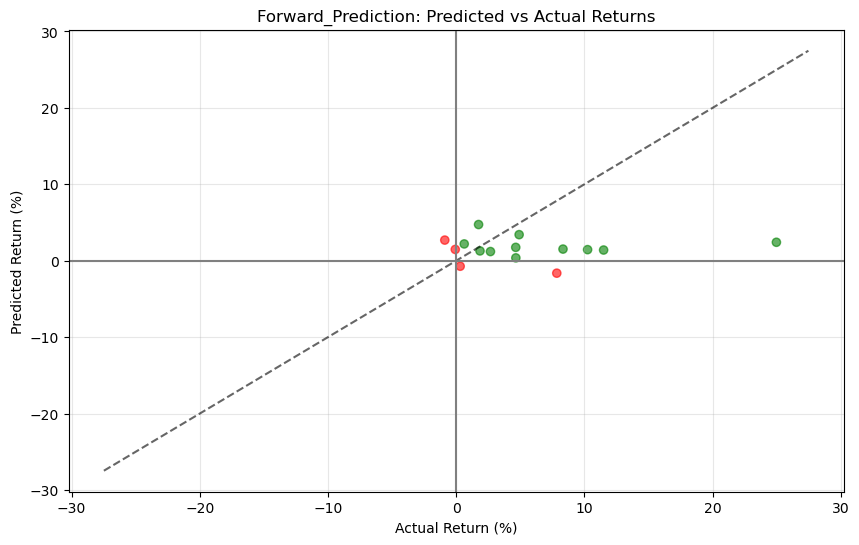

Allocation for $10,000.00:
Your Selected Securities: ['JNJ', 'COKE', 'JPM']...
Successfully calculated returns.
Data merged. final df shape: (82, 13)


,Ticker,Current Price,Pred. Return (%),Allocation %,Cash to Invest,Shares
1,COKE,165.710007,7.788021,58.039784,5799.850235,35.0
0,JNJ,202.479996,3.806508,28.367780,2834.719940,14.0
2,JPM,316.100006,1.823890,13.592436,1264.400024,4.0


In [9]:
tickers = [ "JNJ",'COKE', 'JPM']
#, "SPY", "AAPL", "MSFT", "GOOGL",  "TSLA",, 'JPM', 'COST', 'TEN', 'AMZN', 'VZ', 'BBY','SPY', 'QQQ', 'IWM'
           
initial_capital = 10000

# Stock_Momentum Predictor performance
results = measure_forecast_accuracy(tickers, lookback_years = 0.5)
#results2 = evaluate_model(tickers, )

# Get allocation based on latest data
alloc = predict_and_allocate(tickers, initial_capital)
display(alloc)


In [11]:
type(alloc)

pandas.core.frame.DataFrame

In [10]:
from reportlab.platypus import SimpleDocTemplate, Table, TableStyle
from reportlab.lib import colors
from reportlab.lib.pagesizes import letter
import pandas as pd

def print_out_report(df, filename="output.pdf"):
    #make pdf
    pdf = SimpleDocTemplate(filename, pagesize=letter)
    #turn df into nested list
    data = [df.columns.tolist()] + df.values.tolist()
    #Put in a table format
    table = Table(data)
    #background style
    style = TableStyle([
        ('BACKGROUND', (0,0), (-1,0), colors.lightgrey),
        ('GRID', (0,0), (-1,-1), 0.5, colors.black),
        ('FONT', (0,0), (-1,-1), "Helvetica"),
        ('ALIGN', (0,0), (-1,-1), 'CENTER'),
        ('VALIGN', (0,0), (-1,-1), 'MIDDLE'),
    ])
    table.setStyle(style)

    #Put pdf together
    pdf.build([table])

    return filename


In [12]:
y = print_out_report(alloc,"allocation_report.pdf")


In [13]:
y

'allocation_report.pdf'

In [14]:
from IPython.display import FileLink
FileLink(y)

/Users/alexanderbenjaminvazquez/Desktop/PIC16B/PIC16B_Project/allocation_report.pdf